# Лабораторная работа №2. Кластеризация клиентов интернет-магазина

#### Цель

- освоить методы k-means и агломеративной кластеризации на большом реальном датасете
транзакций
- научиться применять RFM-анализ для сегментации клиентов
- определять оптимальное число кластеров с помощью метода локтя и силуэтного анализа
- интерпретировать кластеры как бизнес-сегменты

#### Датасет

Online Retail по покупкам в интернет-магазине, локализованном в регионе с
индексом 1, пользователями из 39 регионов - 541 909 транзакций, 4 372 клиента, по ссылке
https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/edit?usp=sharing&ouid=114596079979601215791&rtpof=true&sd=true

#### Задача

Сегментировать клиентов по их покупательскому поведению, чтобы отдел маркетинга мог запускать таргетированные кампании: удерживать «ценных», реактивировать «спящих», стимулировать «новичков».

#### Признаки

| Признак | Описание |
|---|---|
| **InvoiceNo** | Номер счёта (6 цифр, уникальный для каждой транзакции) |
| **StockCode** | Код товара (5 цифр) |
| **Description** | Название товара |
| **Quantity** | Количество единиц товара в транзакции |
| **InvoiceDate** | Дата и время выставления счёта |
| **UnitPrice** | Цена за единицу товара |
| **CustomerID** | Идентификатор клиента (5 цифр) |
| **Region** | Код региона проживания клиента |

## Задание 1. Загрузка и EDA

In [152]:
import pandas as pd

In [153]:
df = pd.read_excel('https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/export?format=xlsx&id=1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Region
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-12-01 08:26:00,285.60,17850.0,1
1,536365,71053,WHITE METAL LANTERN,6,2024-12-01 08:26:00,379.68,17850.0,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-12-01 08:26:00,308.00,17850.0,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-12-01 08:26:00,379.68,17850.0,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-12-01 08:26:00,379.68,17850.0,1


In [154]:
print(f'Строк: {len(df)}')
print(f'Пропуски:\n{df.isna().sum()}')
df = df.dropna(subset=['CustomerID'])
# df['CustomerID'] = df['CustomerID'].astype(int)
df_returns = df[df['Quantity'] <= 0].copy()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
print('\n')
print('ПОСЛЕ ОЧИСТКИ')
print(f'Покупок: {len(df)}')
print(f'Возвратов: {len(df_returns)}')
print(f'Уникальных клиентов: {df['CustomerID'].nunique()}')
print(f'Пропуски:\n{df.isna().sum()}')

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Строк: 541909
Пропуски:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Region              0
dtype: int64


ПОСЛЕ ОЧИСТКИ
Покупок: 397884
Возвратов: 8905
Уникальных клиентов: 4338
Пропуски:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Region         0
dtype: int64


In [155]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,397884.000000,397884.000000,3.978840e+05
mean,12.988238,349.046629,2.508464e+03
std,179.331775,2474.962183,3.461596e+04
min,1.000000,0.112000,1.120000e-01
25%,2.000000,140.000000,5.241600e+02
50%,6.000000,218.400000,1.321600e+03
75%,12.000000,420.000000,2.217600e+03
max,80995.000000,911988.000000,1.886860e+07


Видно большой std относительно mean - большой разброс.
max сильно больше 75% - выбросы.



In [156]:
df['Region'].value_counts().head(10)

Region
1     354321
9       9040
2       8341
5       7236
7       2484
4       2359
13      2031
22      1841
28      1462
3       1182
Name: count, dtype: int64

По числу транзакций доминирует регион 1.

In [157]:
import matplotlib.pyplot as plt

%matplotlib inline

In [158]:
monthly = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
print(monthly)

InvoiceDate
2024-12-31    6.414396e+07
2025-01-31    6.377784e+07
2025-02-28    5.007938e+07
2025-03-31    6.669609e+07
2025-04-30    5.255044e+07
2025-05-31    7.600259e+07
2025-06-30    7.405593e+07
2025-07-31    6.721019e+07
2025-08-31    7.227852e+07
2025-09-30    1.067179e+08
2025-10-31    1.164037e+08
2025-11-30    1.301235e+08
2025-12-31    5.803759e+07
Freq: ME, Name: TotalPrice, dtype: float64


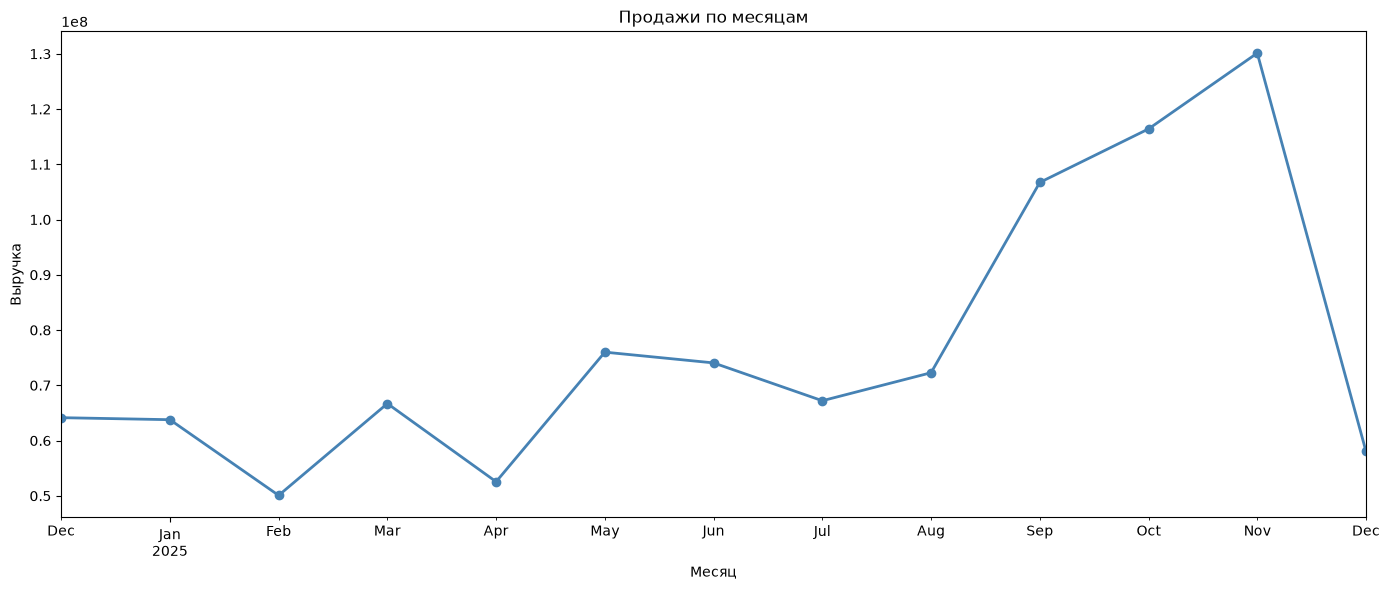

In [159]:
plt.figure(figsize=(14, 6))
monthly.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.tight_layout()
plt.show()

Пик ближе к концу 2025 года, данные за декабрь не полные.

## Задание 2. RFM-анализ (Recency, Frequency, Monetary)

In [160]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [161]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,8644563.20
12347.0,2,7,482720.00
12348.0,75,4,201290.88
12349.0,19,1,196845.60
12350.0,310,1,37452.80


In [162]:
from sklearn.preprocessing import StandardScaler

In [163]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [164]:
import seaborn as sns

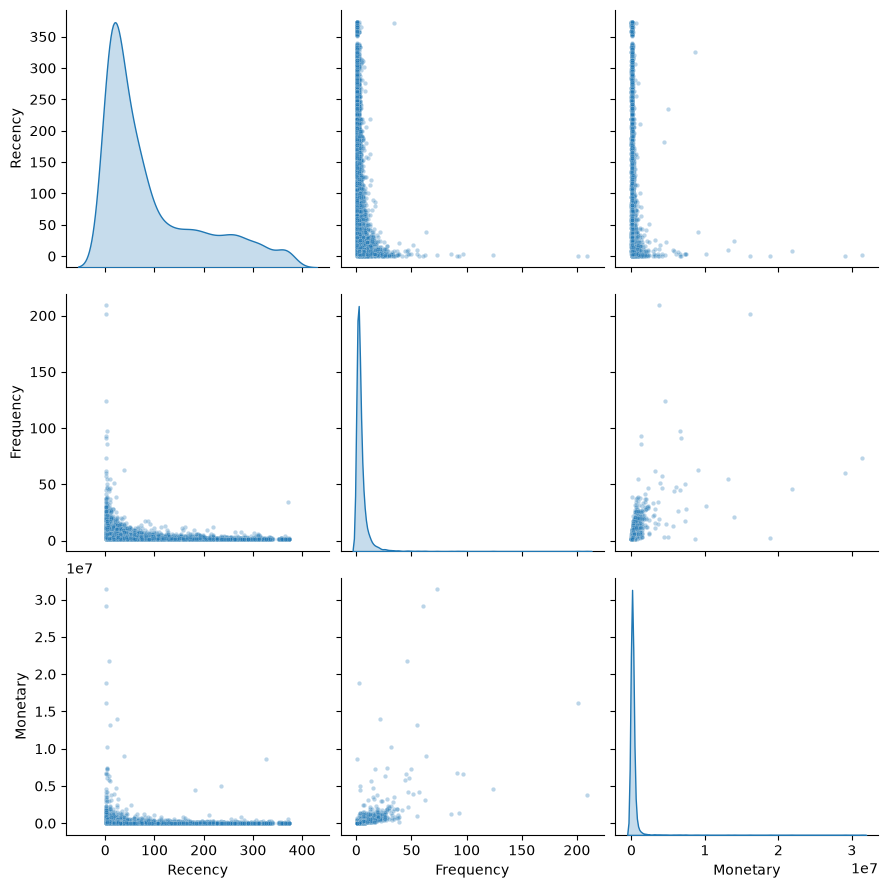

In [165]:
sns.pairplot(rfm, diag_kind='kde', height=3, plot_kws={'alpha': 0.3, 's': 10})

In [166]:
import numpy as np

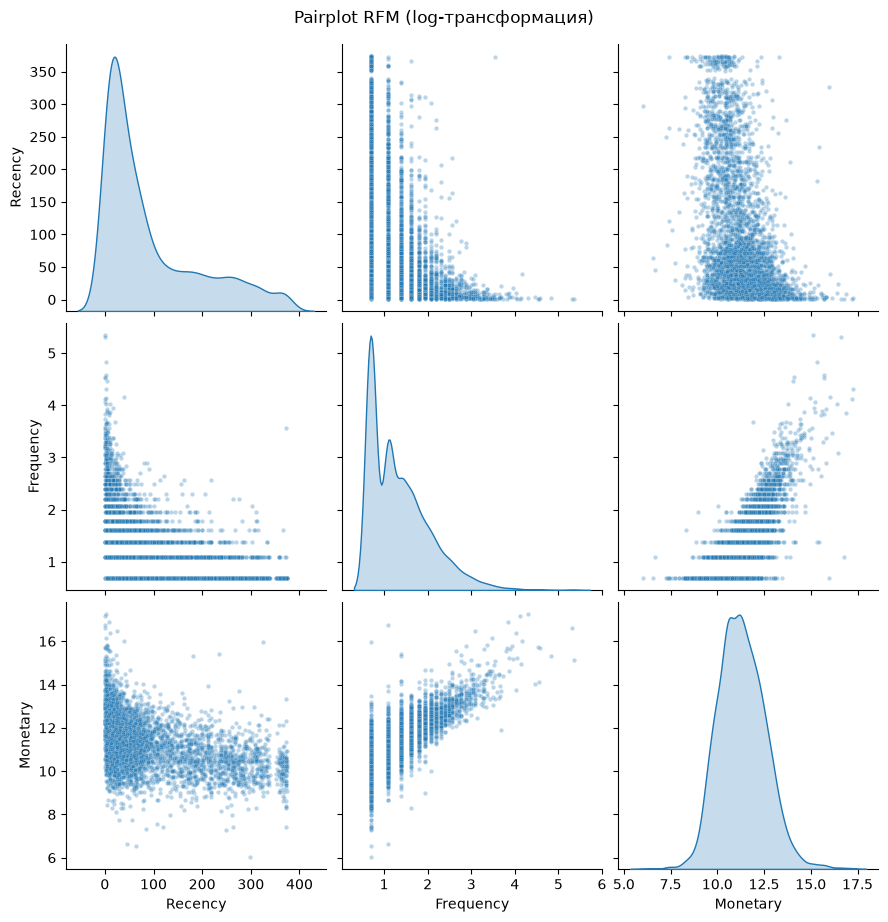

In [167]:
# Логарифмируем Frequency и Monetary
rfm_log = rfm.copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# Pairplot на логарифмированных данных
sns.pairplot(rfm_log, diag_kind='kde', height=3, plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot RFM (log-трансформация)', y=1.02)
plt.show()

- На гистограмме R видно много клиентов покупающих недавно.
- На гистограмме F видно два пика, первый пик - клиенты покупающие один раз, второй - больше.
- На гистограмме M видно нормально распределение.
- На F x M видна зависимость - чем чаще покупают тем больше сумма.
- На R x M снизу видны аномалии с около нулевой суммой.

"На глаз" видно две группы, покупающие недавно часто и покупающие давно и редко.

## Задание 3. Определение оптимального числа кластеров

In [168]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

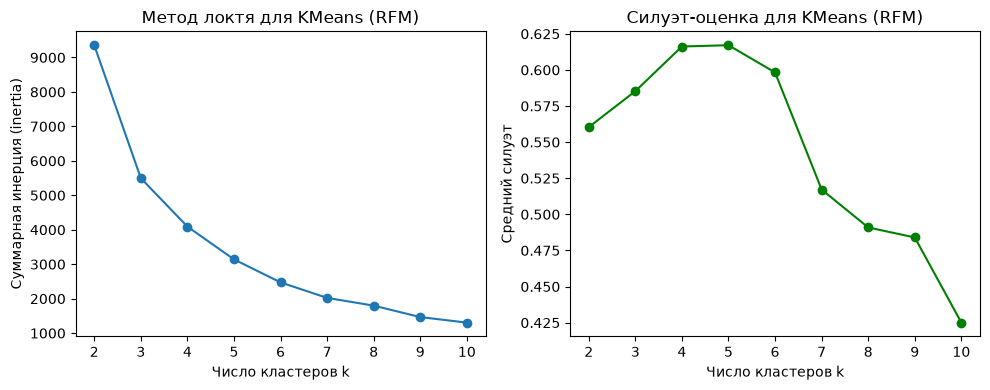

Оптимальное число кластеров по максимальной силуэт-оценке: 5


In [169]:
inertia = []
silhouette_scores = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Число кластеров k')
plt.ylabel('Суммарная инерция (inertia)')
plt.title('Метод локтя для KMeans (RFM)')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.xlabel('Число кластеров k')
plt.ylabel('Средний силуэт')
plt.title('Силуэт-оценка для KMeans (RFM)')
plt.tight_layout()
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'Оптимальное число кластеров по максимальной силуэт-оценке: {optimal_k}')

- В данном случае по методу локтя тяжело определить точное k, k от трех до пяти.
- silhouette максимален при k = 4

k = 4 находится в диапазоне метода локтя.

Силуэт часто даёт k = 2, а метод локтя - от k = 3 до k = 5 потому что, silhouette измеряет насколько точки далеки от соседей, а локоть измеряет насколько точки близки к центрам.

Выбираем k = 4, т.к. 4 соответствет отценке silhouette, попадает в метод локтя и согласуется с бизнес логикой - VIP,
постоянные, новые, потерянные.

## Задание 4. KMeans при k = 2, 3, 4, 5

In [170]:

def rfm_Kmeans(k):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    rfm_log['Cluster'] = labels
    silhouette = silhouette_score(rfm_scaled, labels)
    print(f'k={k}: silhouette = {silhouette:.4f}')
    # Pairplot на логарифмированных данных
    sns.pairplot(
        rfm_log,
        hue='Cluster',
        palette='tab10',
        diag_kind='kde',
        height=3,
        plot_kws={'alpha': 0.4, 's': 10}
    )
    plt.suptitle(f'Pairplot RFM (log), k={k}, silhouette={silhouette:.3f}', y=1.02)
    plt.show()

k=2: silhouette = 0.5604


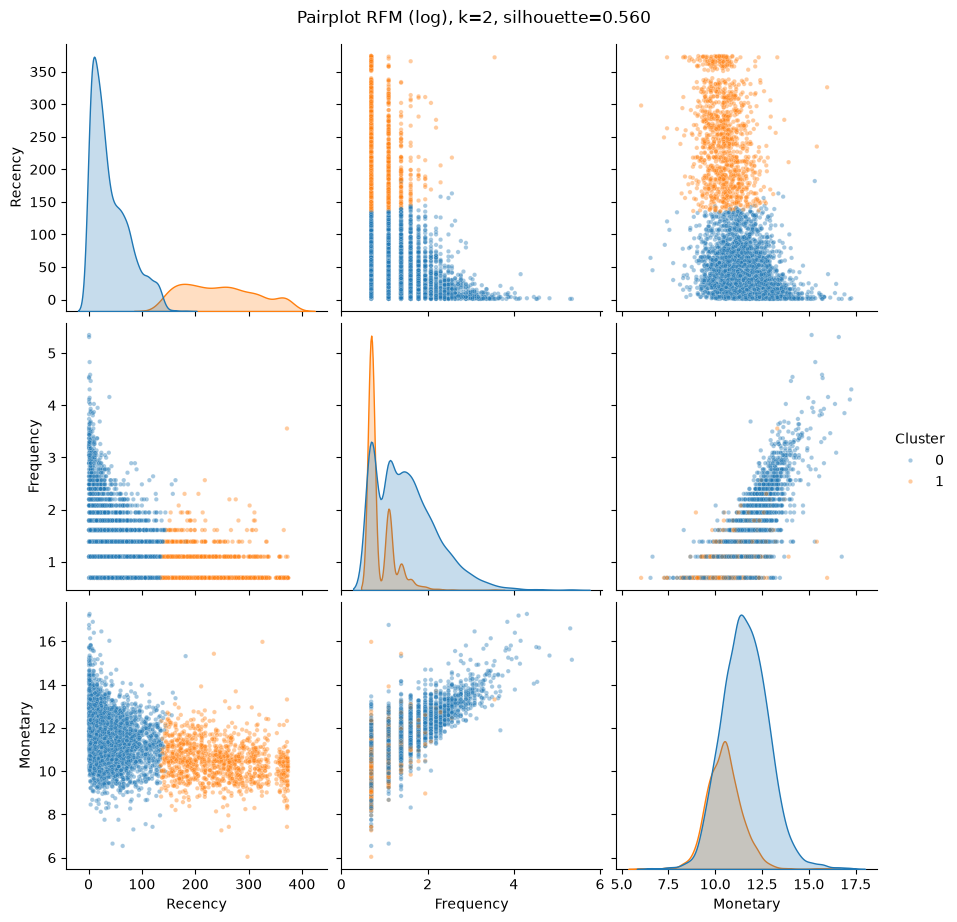

In [171]:
# для k = 2
rfm_Kmeans(2)

k=3: silhouette = 0.5853


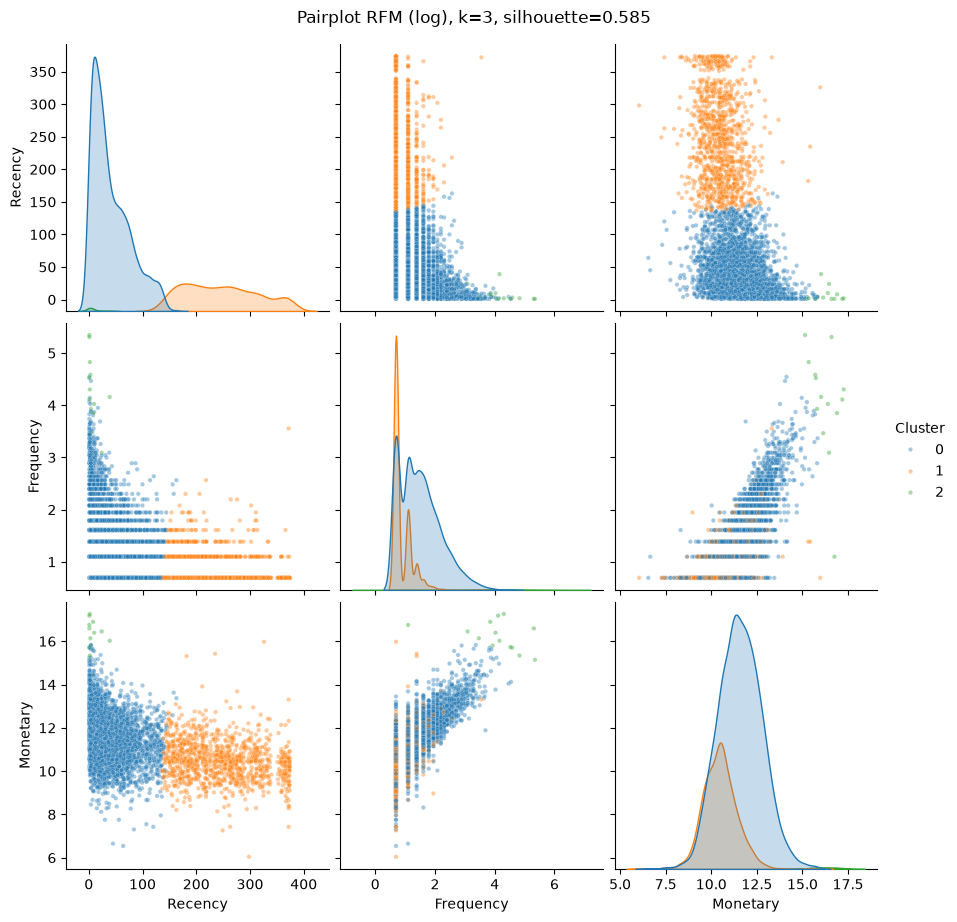

In [172]:
# для k = 3
rfm_Kmeans(3)

k=4: silhouette = 0.6162


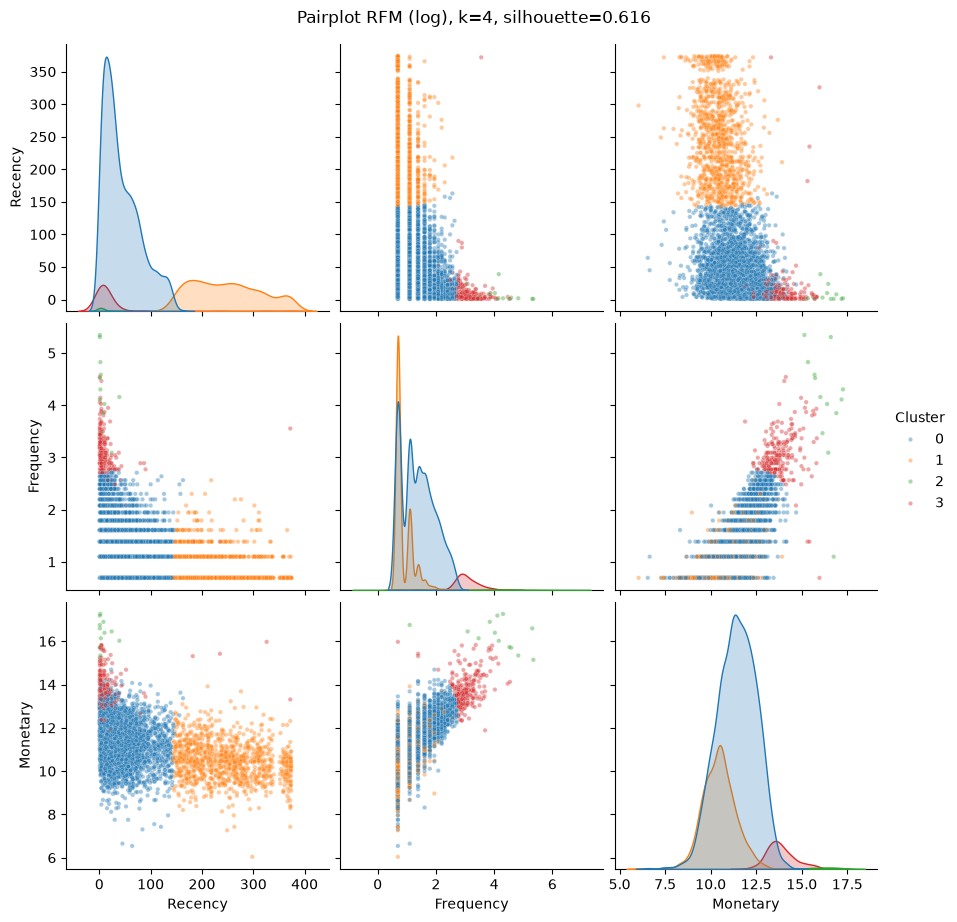

In [173]:
# для k = 4
rfm_Kmeans(4)

k=5: silhouette = 0.6171


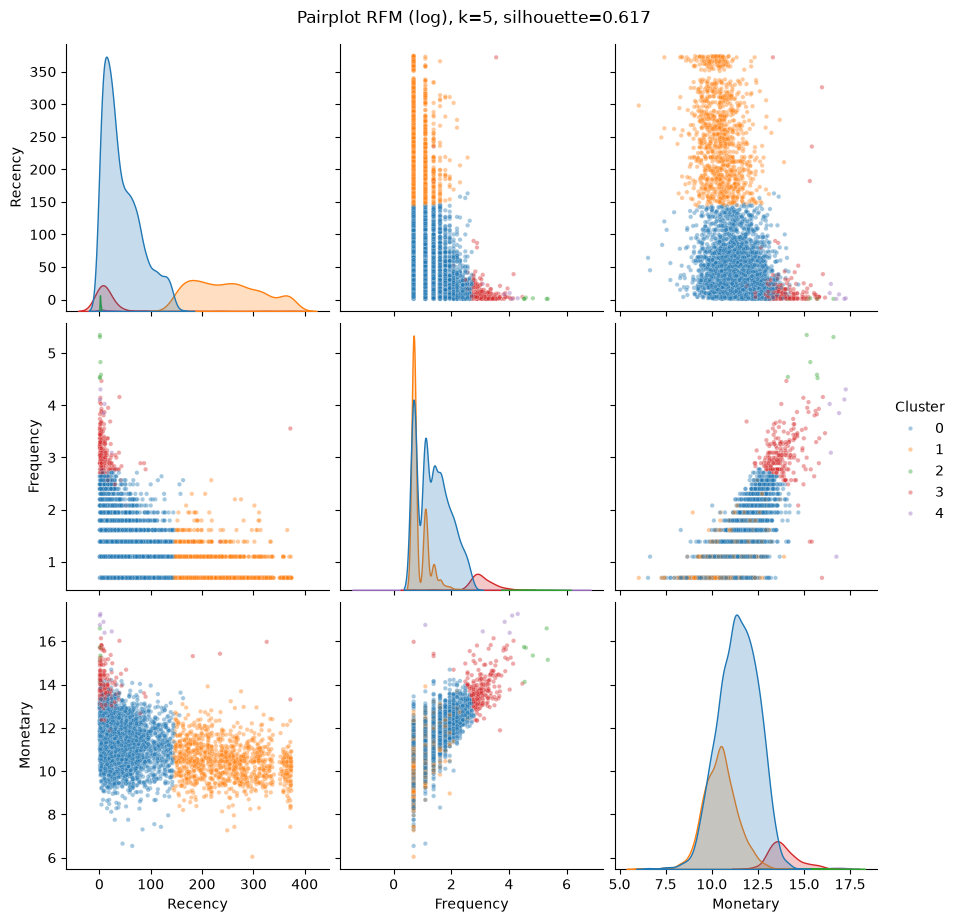

In [174]:
# для k = 5
rfm_Kmeans(5)

#### silhouette plot для всех вариантов k

In [175]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

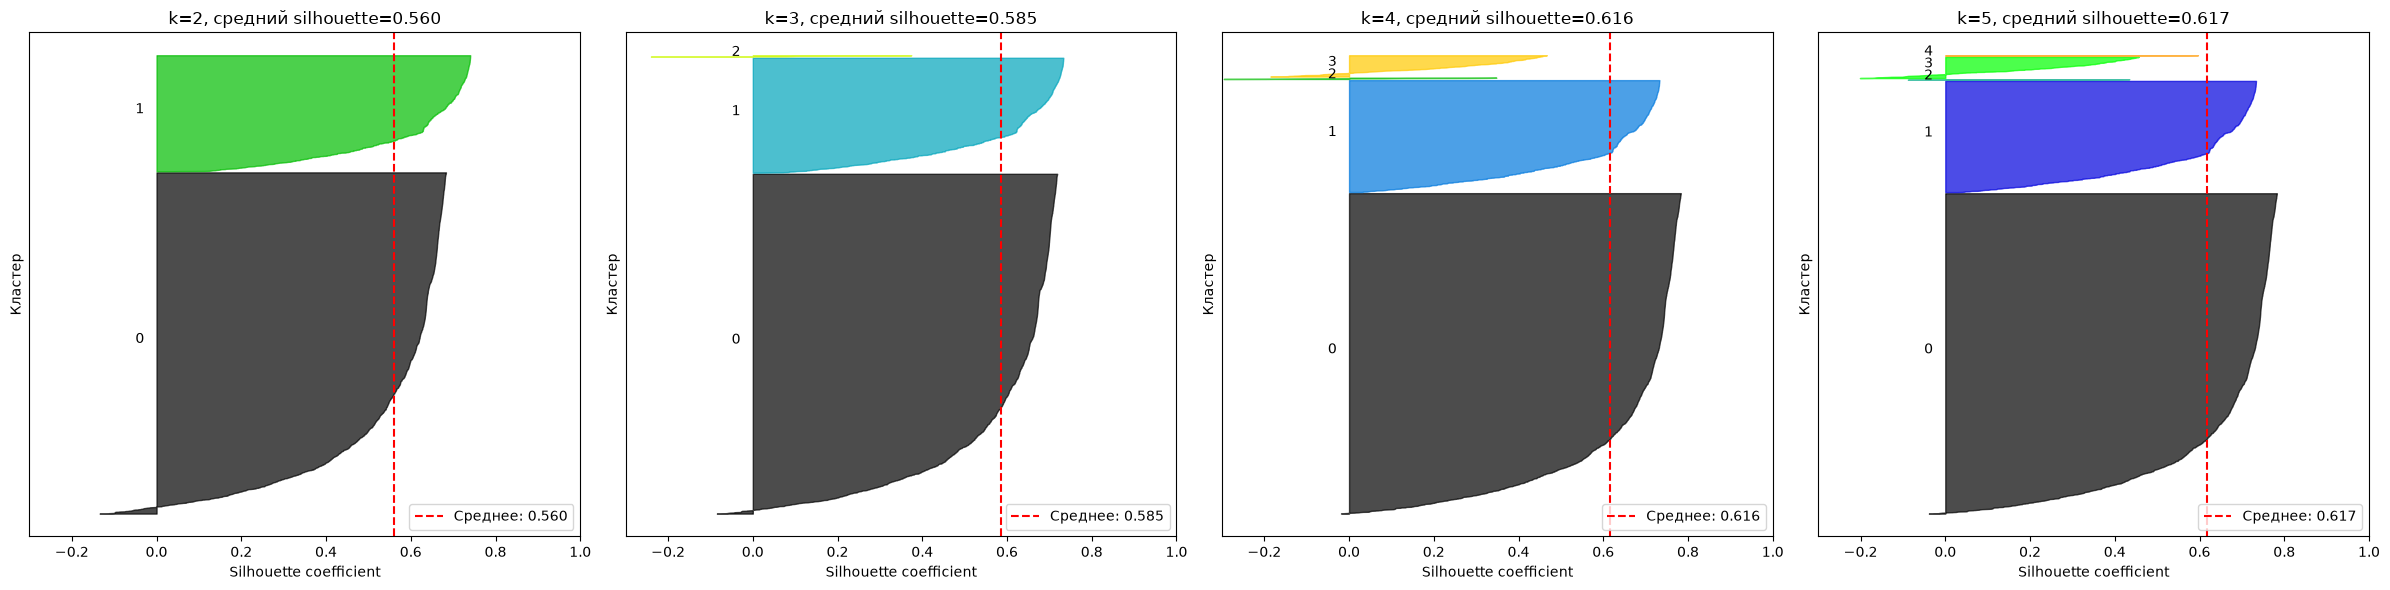

In [176]:
# Функция для silhouette plot
def silhouette_plot(X, k, ax):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    
    sil_vals = silhouette_samples(X, labels)
    sil_avg = silhouette_score(X, labels)
    
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_vals[labels == i])
        size = len(cluster_vals)
        y_upper = y_lower + size
        
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10
    
    ax.axvline(x=sil_avg, color='red', linestyle='--',
               label=f'Среднее: {sil_avg:.3f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Кластер')
    ax.set_title(f'k={k}, средний silhouette={sil_avg:.3f}')
    ax.set_yticks([])
    ax.legend(loc='lower right')
    ax.set_xlim([-0.3, 1])

# Строим для k = 2, 3, 4, 5
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, k in zip(axes, [2, 3, 4, 5]):
    silhouette_plot(rfm_scaled, k, ax)

plt.tight_layout()
plt.show()

- Средний силуэт выше при k = 4.
- На всех графиках есть точки с отрицательным силуэтом.
- У кластеров мечи не ровные и есть выбивающиеся кластеры.

#### Профиль кластеров для всех k

In [177]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    
    rfm_temp = rfm.copy()
    rfm_temp['Cluster'] = labels
    
    profile = rfm_temp.groupby('Cluster').agg(
        Recency=('Recency', 'mean'),
        Frequency=('Frequency', 'mean'),
        Monetary=('Monetary', 'mean'),
        Size=('Recency', 'count')
    ).round(1)
    
    profile = profile.sort_values('Monetary', ascending=False)
    
    # print(f'{'='*50}')
    print(f'k = {k}')
    print(profile)

k = 2
         Recency  Frequency  Monetary  Size
Cluster                                    
0           40.6        5.2  285657.4  3237
1          245.2        1.6   66670.8  1101
k = 3
         Recency  Frequency    Monetary  Size
Cluster                                      
2            7.1       80.2  13763501.6    14
0           41.0        4.9    225356.5  3231
1          246.0        1.6     70687.8  1093
k = 4
         Recency  Frequency    Monetary  Size
Cluster                                      
2            7.4       82.5  14261891.2    13
3           15.5       22.3   1423418.1   204
0           43.7        3.7    152213.5  3054
1          248.1        1.6     53829.2  1067
k = 5
         Recency  Frequency    Monetary  Size
Cluster                                      
4            7.7       42.8  21376707.7     6
2            1.5      135.8   6538685.8     6
3           15.7       22.3   1515807.7   203
0           43.8        3.7    152182.7  3060
1          248.5  

- При k = 4 силуэт выше.
- При k = 4 кластеры интерпретируемы как бизнес-сегменты.
- При k = 4, судя по графику, кластер 2 перетягивает силуэт вниз. Monetary = 13922978.3 - выброс.

## Задание 5. Агломеративная кластеризация

In [178]:
K_range = [2, 3, 4, 5]
linkages = ['ward', 'complete', 'average', 'single']

# Таблица результатов
results = []

for linkage in linkages:
    for k in K_range:
        hier = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = hier.fit_predict(rfm_scaled)
        sil = silhouette_score(rfm_scaled, labels)
        results.append({
            'linkage': linkage,
            'k': k,
            'silhouette': round(sil, 4)
        })
        
df_results = pd.DataFrame(results)
pivot = df_results.pivot(index='linkage', columns='k', values='silhouette')
print(pivot)

k              2       3       4       5
linkage                                 
average   0.9462  0.9269  0.9078  0.8884
complete  0.9413  0.9417  0.8573  0.8572
single    0.9483  0.9427  0.9434  0.9316
ward      0.5614  0.6041  0.6065  0.6073


In [179]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4.338000e+03
mean,92.536422,4.272015,2.300778e+05
std,100.014169,7.697998,1.006794e+06
min,1.000000,1.000000,4.200000e+02
25%,18.000000,1.000000,3.443048e+04
50%,51.000000,2.000000,7.554232e+04
75%,142.000000,5.000000,1.861149e+05
max,374.000000,209.000000,3.138307e+07


In [180]:
print(f"rfm_scaled mean: {rfm_scaled.mean(axis=0)}")
print(f"rfm_scaled std:  {rfm_scaled.std(axis=0)}")
# Должно быть: mean ≈ 0, std ≈ 1

rfm_scaled mean: [2.70261760e-17 1.80174507e-17 6.55180024e-18]
rfm_scaled std:  [1. 1. 1.]


In [181]:
for linkage in ['ward', 'complete', 'average', 'single']:
    for k in [2, 3, 4, 5]:
        hier = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = hier.fit_predict(rfm_scaled)
        sizes = np.bincount(labels)
        print(f"{linkage:10s}, k={k}: размеры={sizes}")

ward      , k=2: размеры=[3389  949]
ward      , k=3: размеры=[  64  949 3325]
ward      , k=4: размеры=[  56    8 3325  949]
ward      , k=5: размеры=[3325    8    7  949   49]
complete  , k=2: размеры=[4334    4]
complete  , k=3: размеры=[4332    4    2]
complete  , k=4: размеры=[   4 4318    2   14]
complete  , k=5: размеры=[4318   14    2    2    2]
average   , k=2: размеры=[4336    2]
average   , k=3: размеры=[   7    2 4329]
average   , k=4: размеры=[4329    2    5    2]
average   , k=5: размеры=[   2 4324    5    2    5]
single    , k=2: размеры=[4337    1]
single    , k=3: размеры=[4336    1    1]
single    , k=4: размеры=[4334    2    1    1]
single    , k=5: размеры=[4333    2    1    1    1]


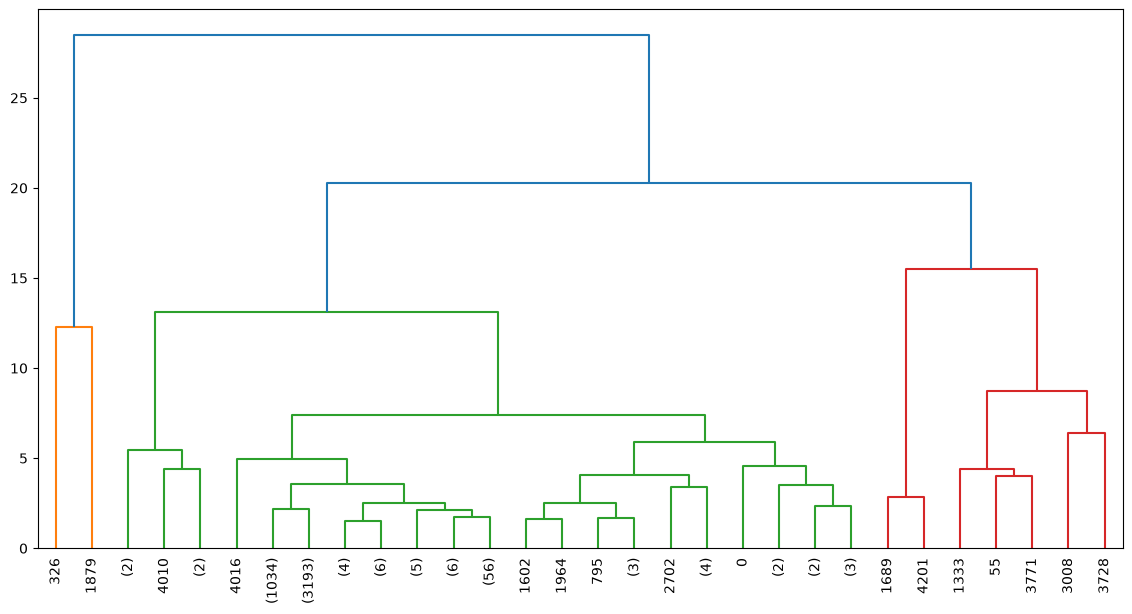

In [183]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(rfm_scaled, method='average')
plt.figure(figsize=(14, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
# plt.axhline(y=..., color='r', linestyle='--')
plt.show()